In [ ]:
!pip install librosa tqdm scikit-learn

In [ ]:
import os
import numpy as np
import librosa
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/TORGO"


In [ ]:
def compute_ssi2(wav_path, sr=16000):
    try:
        y, sr = librosa.load(wav_path, sr=sr, duration=4.0)
    except:
        return None

    if len(y) < sr * 0.5:
        return None

    # ---- Pitch instability ----
    f0 = librosa.yin(y, fmin=80, fmax=300, sr=sr)
    f0 = f0[~np.isnan(f0)]
    if len(f0) < 10:
        return None

    delta_f0 = np.diff(f0)
    S_pitch = np.std(delta_f0) / (np.mean(f0) + 1e-6)

    # ---- Energy instability ----
    energy = librosa.feature.rms(y=y)[0]
    delta_energy = np.diff(energy)
    S_energy = np.std(delta_energy) / (np.mean(energy) + 1e-6)

    return (S_pitch + S_energy) / 2

In [ ]:
wav_data = []

folders = ["F_Con", "M_Con", "F_Dys", "M_Dys"]

for folder in folders:
    folder_path = os.path.join(DATASET_ROOT, folder)
    label = 0 if folder in ["F_Con", "M_Con"] else 1

    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".wav"):
                wav_path = os.path.join(root, file)
                speaker_id = root.split("/")[-1]
                wav_data.append((wav_path, speaker_id, label))

print("Total wav files:", len(wav_data))

Total wav files: 0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("Speaker-level AUC:", auc)

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/SSI_Project"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(f"{SAVE_DIR}/X_speaker_ssi2.npy", X_speaker)
np.save(f"{SAVE_DIR}/y_speaker.npy", y_speaker)

In [ ]:
X_features = []
y_labels = []

for spk in speaker_ssi:
    values = np.array(speaker_ssi[spk])

    mean_val = np.mean(values)
    std_val = np.std(values)
    p75_val = np.percentile(values, 75)
    max_val = np.max(values)

    X_features.append([mean_val, std_val, p75_val, max_val])
    y_labels.append(speaker_label[spk])

X_features = np.array(X_features)
y_labels = np.array(y_labels)

print("Feature shape:", X_features.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_labels,
    test_size=0.3,
    random_state=42,
    stratify=y_labels
)

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)

print("Improved Speaker-Level AUC:", auc)

In [ ]:
def compute_motor_features(wav_path, sr=16000):
    try:
        y, sr = librosa.load(wav_path, sr=sr, duration=4.0)
    except:
        return None

    if len(y) < sr * 0.5:
        return None

    # ---- Pitch ----
    try:
        f0 = librosa.yin(y, fmin=80, fmax=300, sr=sr)
    except:
        return None

    f0 = f0[~np.isnan(f0)]
    if len(f0) < 5:   # relaxed condition
        return None

    delta_f0 = np.diff(f0)
    pitch_instability = np.std(delta_f0) / (np.mean(f0) + 1e-6)
    pitch_range = np.max(f0) - np.min(f0)
    pitch_variability = np.std(f0)

    # ---- Energy ----
    energy = librosa.feature.rms(y=y)[0]
    delta_energy = np.diff(energy)
    energy_instability = np.std(delta_energy) / (np.mean(energy) + 1e-6)
    energy_range = np.max(energy) - np.min(energy)

    # ---- Articulation ----
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_variability = np.mean(np.std(mfcc, axis=1))

    return [
        pitch_instability,
        energy_instability,
        pitch_range,
        energy_range,
        pitch_variability,
        mfcc_variability
    ]

In [ ]:
wav_data = []

folders = ["F_Con", "M_Con", "F_Dys", "M_Dys"]

for folder in folders:
    folder_path = os.path.join(DATASET_ROOT, folder)
    label = 0 if folder in ["F_Con", "M_Con"] else 1

    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".wav"):
                wav_path = os.path.join(root, file)
                speaker_id = root.split("/")[-1]
                wav_data.append((wav_path, speaker_id, label))

print("Total wav files:", len(wav_data))

Total wav files: 17635


In [ ]:
X = []
y = []

for spk in speaker_features:
    values = np.array(speaker_features[spk])

    mean_features = np.mean(values, axis=0)
    std_features = np.std(values, axis=0)

    combined = np.concatenate([mean_features, std_features])
    X.append(combined)
    y.append(speaker_label[spk])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Healthy speakers:", np.sum(y == 0))
print("Dys speakers:", np.sum(y == 1))

Feature shape: (55, 12)
Healthy speakers: 28
Dys speakers: 27


In [ ]:
print("Feature shape:", X.shape)
print("Labels shape:", y.shape)
print("Healthy speakers:", np.sum(y == 0))
print("Dys speakers:", np.sum(y == 1))

Feature shape: (55, 12)
Labels shape: (55,)
Healthy speakers: 28
Dys speakers: 27


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("SSI 3.0 Speaker-Level AUC:", auc)

SSI 3.0 Speaker-Level AUC: 0.8194444444444445


In [ ]:
import pandas as pd

feature_names = [
    "pitch_inst_mean",
    "energy_inst_mean",
    "pitch_range_mean",
    "energy_range_mean",
    "pitch_var_mean",
    "mfcc_var_mean",
    "pitch_inst_std",
    "energy_inst_std",
    "pitch_range_std",
    "energy_range_std",
    "pitch_var_std",
    "mfcc_var_std"
]

importance = pd.Series(clf.coef_[0], index=feature_names)
print(importance.sort_values(ascending=False))

pitch_var_std        1.030817
mfcc_var_mean        0.771136
pitch_range_mean     0.587424
energy_range_std     0.502471
pitch_var_mean       0.404984
energy_inst_std      0.235594
pitch_range_std      0.062317
energy_inst_mean     0.057966
energy_range_mean   -0.189723
mfcc_var_std        -0.260584
pitch_inst_std      -0.625325
pitch_inst_mean     -1.442317
dtype: float64


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Use pipeline so scaling happens inside CV (important!)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Fold AUCs:", scores)
print("Mean CV AUC:", scores.mean())
print("Std CV AUC:", scores.std())

Fold AUCs: [0.83333333 0.93333333 0.76666667 0.66666667 0.93333333]
Mean CV AUC: 0.8266666666666665
Std CV AUC: 0.10198039027185572


In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import numpy as np

# Leave-One-Out CV — gold standard for small N datasets
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

loo = LeaveOneOut()
y_true_all = []
y_prob_all = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipeline.fit(X_train, y_train)
    prob = pipeline.predict_proba(X_test)[0, 1]

    y_true_all.append(y_test[0])
    y_prob_all.append(prob)

loo_auc = roc_auc_score(y_true_all, y_prob_all)
print(f"Leave-One-Out AUC: {loo_auc:.4f}")
print(f"(Previous train/test AUC was 0.8194 — LOOCV is more honest)")

Leave-One-Out AUC: 0.8228
(Previous train/test AUC was 0.8194 — LOOCV is more honest)


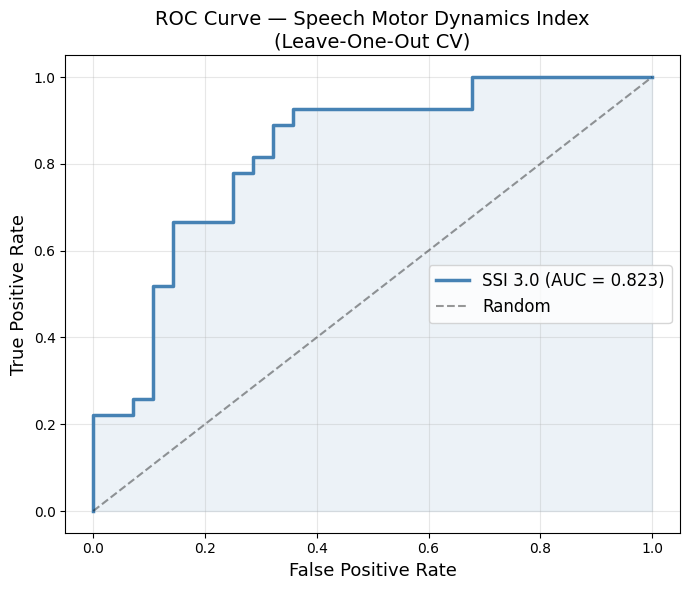

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true_all, y_prob_all)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'SSI 3.0 (AUC = {loo_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — Speech Motor Dynamics Index\n(Leave-One-Out CV)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

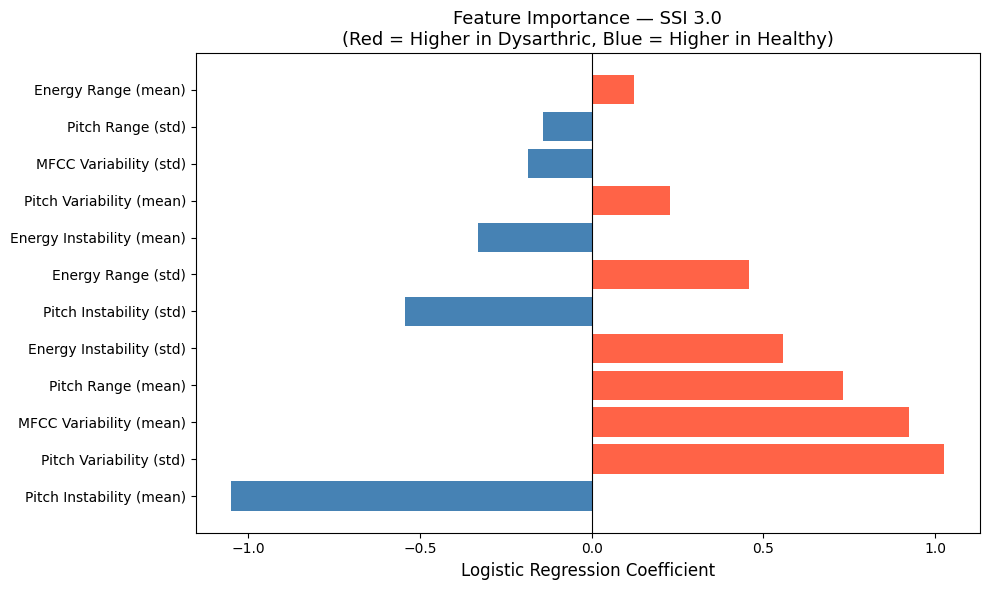


Top 3 most discriminative features:
  Pitch Instability (mean): LOWER in dysarthric
  Pitch Variability (std): HIGHER in dysarthric
  MFCC Variability (mean): HIGHER in dysarthric


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

feature_names = [
    'Pitch Instability (mean)', 'Energy Instability (mean)',
    'Pitch Range (mean)', 'Energy Range (mean)',
    'Pitch Variability (mean)', 'MFCC Variability (mean)',
    'Pitch Instability (std)', 'Energy Instability (std)',
    'Pitch Range (std)', 'Energy Range (std)',
    'Pitch Variability (std)', 'MFCC Variability (std)'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_scaled, y)

coefs = clf.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))[::-1]

colors = ['tomato' if c > 0 else 'steelblue' for c in coefs[sorted_idx]]

plt.figure(figsize=(10, 6))
bars = plt.barh([feature_names[i] for i in sorted_idx], coefs[sorted_idx], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Logistic Regression Coefficient', fontsize=12)
plt.title('Feature Importance — SSI 3.0\n(Red = Higher in Dysarthric, Blue = Higher in Healthy)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 3 most discriminative features:")
for i in sorted_idx[:3]:
    direction = 'HIGHER in dysarthric' if coefs[i] > 0 else 'LOWER in dysarthric'
    print(f"  {feature_names[i]}: {direction}")

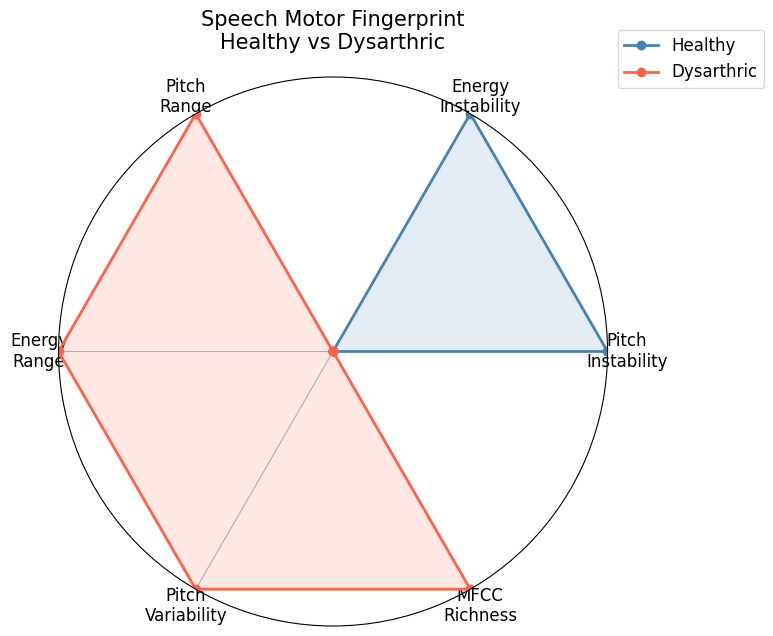

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Use mean of first 6 features (interpretable ones)
radar_feature_names = [
    'Pitch\nInstability', 'Energy\nInstability',
    'Pitch\nRange', 'Energy\nRange',
    'Pitch\nVariability', 'MFCC\nRichness'
]

healthy_mean = np.mean(X[y == 0, :6], axis=0)
dys_mean = np.mean(X[y == 1, :6], axis=0)

# Normalize to 0-1 for radar
combined = np.vstack([healthy_mean, dys_mean])
min_vals = combined.min(axis=0)
max_vals = combined.max(axis=0)
healthy_norm = (healthy_mean - min_vals) / (max_vals - min_vals + 1e-6)
dys_norm = (dys_mean - min_vals) / (max_vals - min_vals + 1e-6)

N = len(radar_feature_names)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

healthy_vals = healthy_norm.tolist() + [healthy_norm[0]]
dys_vals = dys_norm.tolist() + [dys_norm[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, healthy_vals, 'o-', linewidth=2, color='steelblue', label='Healthy')
ax.fill(angles, healthy_vals, alpha=0.15, color='steelblue')

ax.plot(angles, dys_vals, 'o-', linewidth=2, color='tomato', label='Dysarthric')
ax.fill(angles, dys_vals, alpha=0.15, color='tomato')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_feature_names, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title('Speech Motor Fingerprint\nHealthy vs Dysarthric', fontsize=15, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150)
plt.show()

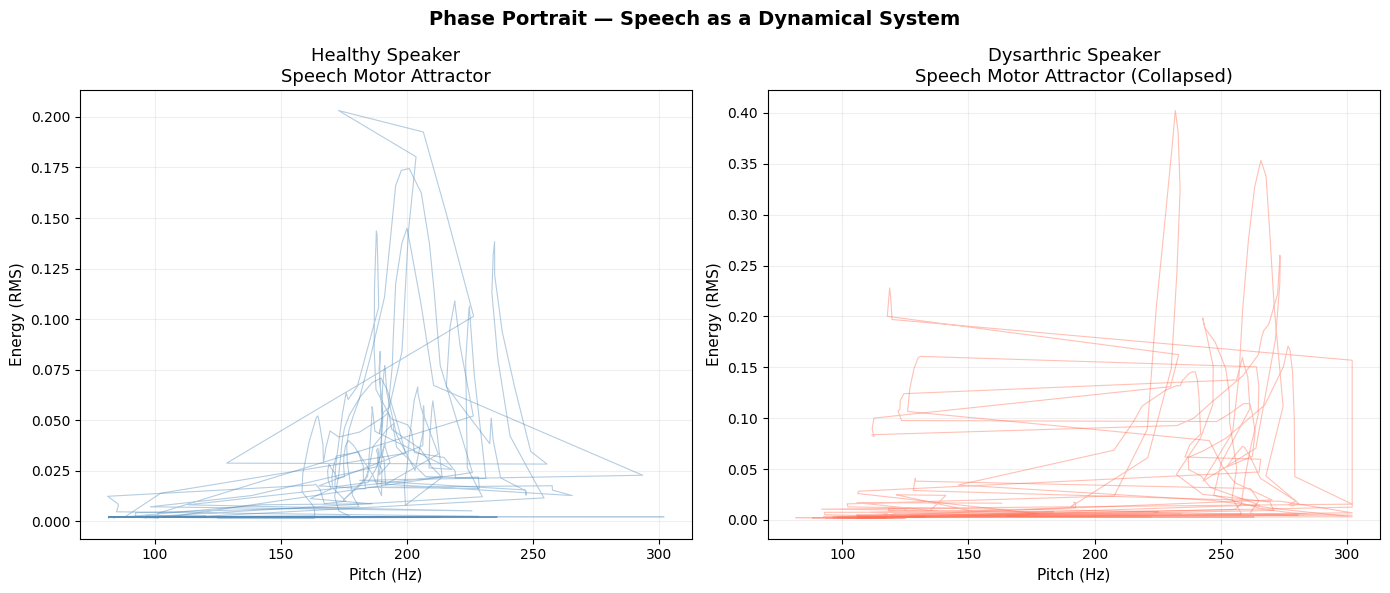

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def get_phase_portrait(wav_path, sr=16000, duration=4.0):
    try:
        y_audio, sr = librosa.load(wav_path, sr=sr, duration=duration)
    except:
        return None, None

    f0 = librosa.yin(y_audio, fmin=80, fmax=300, sr=sr)
    energy = librosa.feature.rms(y=y_audio)[0]

    # Align lengths
    min_len = min(len(f0), len(energy))
    return f0[:min_len], energy[:min_len]

# Pick one healthy and one dysarthric speaker
# Get their WAV files from wav_data
healthy_wavs = [w for w, spk, lbl in wav_data if lbl == 0][:5]
dys_wavs = [w for w, spk, lbl in wav_data if lbl == 1][:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for wav in healthy_wavs:
    f0, en = get_phase_portrait(wav)
    if f0 is not None:
        axes[0].plot(f0, en, alpha=0.4, color='steelblue', linewidth=0.8)

for wav in dys_wavs:
    f0, en = get_phase_portrait(wav)
    if f0 is not None:
        axes[1].plot(f0, en, alpha=0.4, color='tomato', linewidth=0.8)

axes[0].set_title('Healthy Speaker\nSpeech Motor Attractor', fontsize=13)
axes[1].set_title('Dysarthric Speaker\nSpeech Motor Attractor (Collapsed)', fontsize=13)

for ax in axes:
    ax.set_xlabel('Pitch (Hz)', fontsize=11)
    ax.set_ylabel('Energy (RMS)', fontsize=11)
    ax.grid(alpha=0.2)

plt.suptitle('Phase Portrait — Speech as a Dynamical System', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_portrait.png', dpi=150)
plt.show()

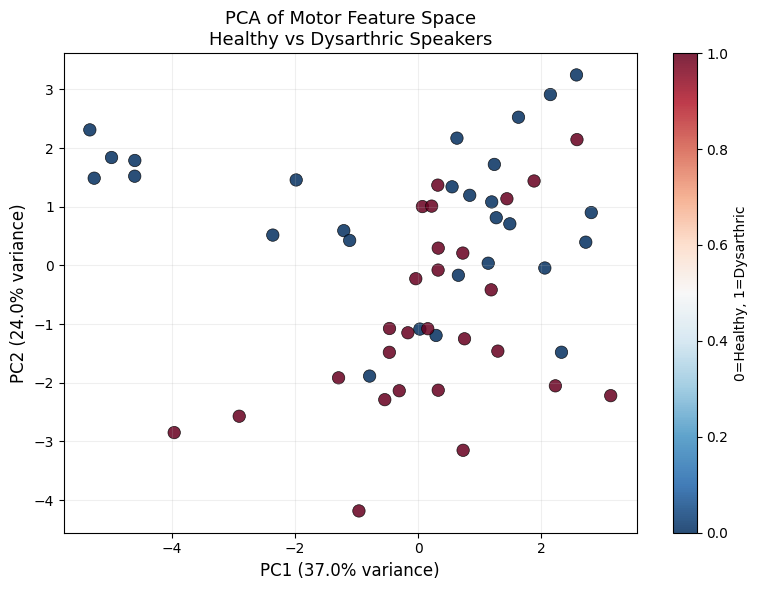

Total variance explained by 2 PCs: 61.0%


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y, cmap='RdBu_r', edgecolors='k',
    linewidths=0.5, s=80, alpha=0.85
)
plt.colorbar(scatter, label='0=Healthy, 1=Dysarthric')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('PCA of Motor Feature Space\nHealthy vs Dysarthric Speakers', fontsize=13)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150)
plt.show()

print(f"Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

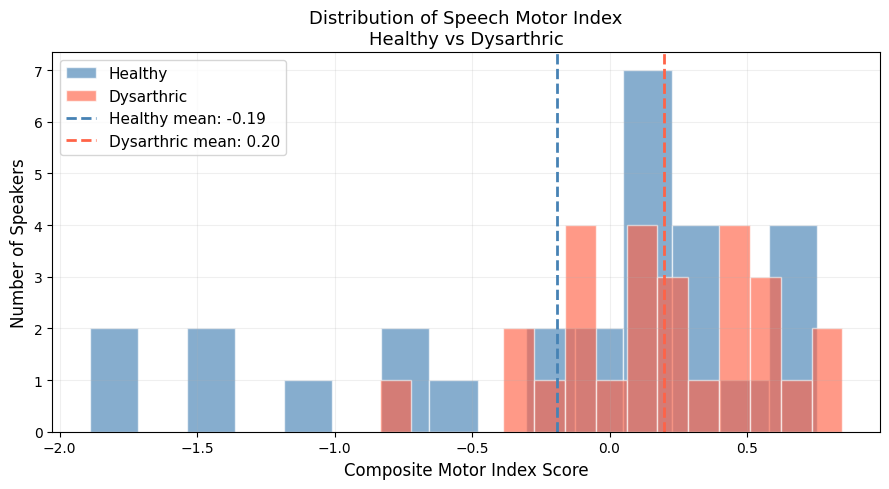

Mann-Whitney U test: p = 0.1007
Not significant (p >= 0.05)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the motor score = mean of first 6 normalized features as composite index
scaler_temp = StandardScaler()
X_norm = scaler_temp.fit_transform(X)
motor_score = np.mean(X_norm[:, :6], axis=1)  # composite motor index

healthy_scores = motor_score[y == 0]
dys_scores = motor_score[y == 1]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(healthy_scores, bins=15, alpha=0.65, color='steelblue', label='Healthy', edgecolor='white')
ax.hist(dys_scores, bins=15, alpha=0.65, color='tomato', label='Dysarthric', edgecolor='white')

ax.axvline(np.mean(healthy_scores), color='steelblue', linestyle='--', linewidth=2, label=f'Healthy mean: {np.mean(healthy_scores):.2f}')
ax.axvline(np.mean(dys_scores), color='tomato', linestyle='--', linewidth=2, label=f'Dysarthric mean: {np.mean(dys_scores):.2f}')

ax.set_xlabel('Composite Motor Index Score', fontsize=12)
ax.set_ylabel('Number of Speakers', fontsize=12)
ax.set_title('Distribution of Speech Motor Index\nHealthy vs Dysarthric', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()

from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(healthy_scores, dys_scores)
print(f"Mann-Whitney U test: p = {pval:.4f}")
print("Statistically significant!" if pval < 0.05 else "Not significant (p >= 0.05)")

  NEURAL MOTOR INDEX (NMI): 14.0 / 100
  Dysarthria Probability:   86.0%
  Risk Level:               HIGH


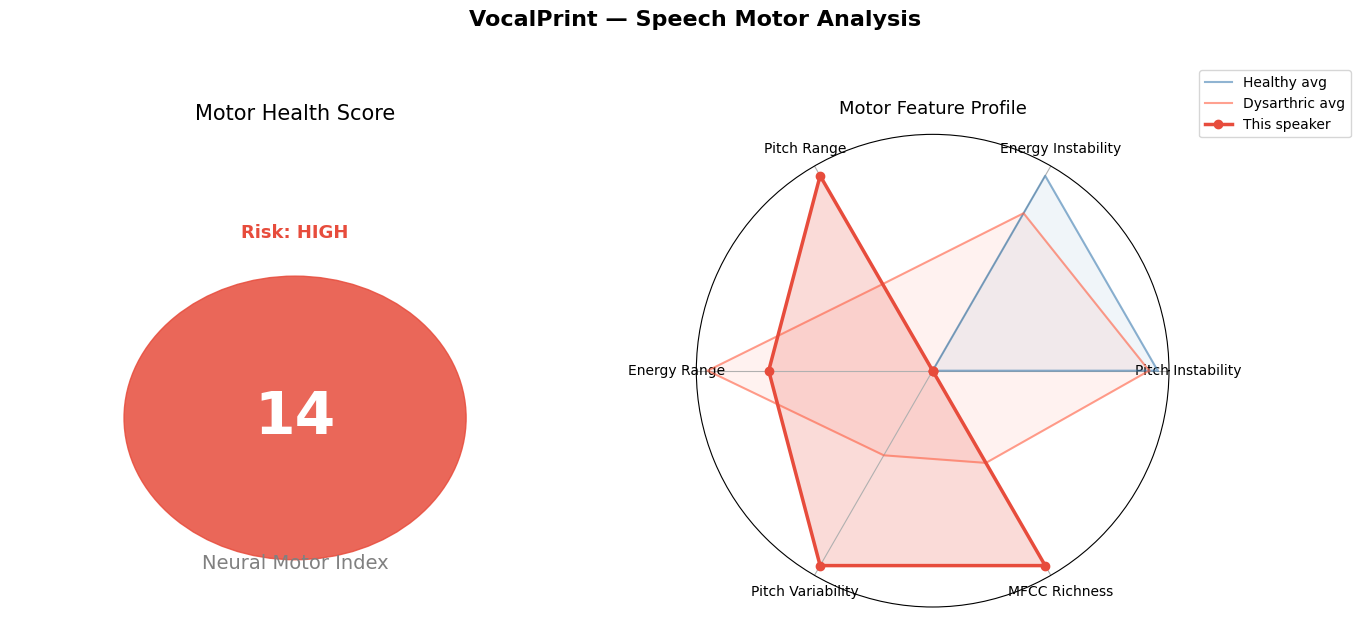

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =============================
# CHANGE THIS TO ANY WAV FILE
TEST_WAV = "/content/drive/MyDrive/TORGO/F_Dys/wav_arrayMic_F01/wav_arrayMic_F01_0001.wav"  # <-- change me
# =============================

feats = compute_motor_features(TEST_WAV)

if feats is None:
    print("Could not process file. Check path or file length.")
else:
    feats = np.array(feats)

    # Score using trained classifier
    feat_full = np.concatenate([feats, np.zeros(6)])  # std unknown for single file
    feat_scaled = scaler.transform([feat_full])
    prob = clf.predict_proba(feat_scaled)[0, 1]
    nmi = (1 - prob) * 100  # Neural Motor Index: 100 = perfectly healthy

    print("=" * 45)
    print(f"  NEURAL MOTOR INDEX (NMI): {nmi:.1f} / 100")
    print(f"  Dysarthria Probability:   {prob*100:.1f}%")
    risk = "LOW" if prob < 0.35 else ("MODERATE" if prob < 0.65 else "HIGH")
    print(f"  Risk Level:               {risk}")
    print("=" * 45)

    # Feature breakdown
    feat_labels = [
        'Pitch Instability', 'Energy Instability',
        'Pitch Range', 'Energy Range',
        'Pitch Variability', 'MFCC Richness'
    ]

    # Radar chart
    healthy_ref = np.mean(X[y == 0, :6], axis=0)
    dys_ref = np.mean(X[y == 1, :6], axis=0)
    combined_ref = np.vstack([healthy_ref, dys_ref, feats])
    min_v = combined_ref.min(axis=0)
    max_v = combined_ref.max(axis=0)

    def norm(v): return (v - min_v) / (max_v - min_v + 1e-6)

    N = len(feat_labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                    subplot_kw={'polar': False})

    # --- Gauge ---
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.axis('off')
    color = '#2ecc71' if nmi > 65 else ('#f39c12' if nmi > 35 else '#e74c3c')
    circle = plt.Circle((0.5, 0.4), 0.3, color=color, alpha=0.85)
    ax1.add_patch(circle)
    ax1.text(0.5, 0.4, f"{nmi:.0f}", ha='center', va='center',
             fontsize=42, fontweight='bold', color='white')
    ax1.text(0.5, 0.08, 'Neural Motor Index', ha='center', fontsize=14, color='gray')
    ax1.text(0.5, 0.78, f'Risk: {risk}', ha='center', fontsize=13,
             color=color, fontweight='bold')
    ax1.set_title('Motor Health Score', fontsize=15, pad=10)

    # --- Radar ---
    ax_radar = fig.add_subplot(122, polar=True)
    fig.delaxes(ax2)

    h_vals = norm(healthy_ref).tolist() + [norm(healthy_ref)[0]]
    d_vals = norm(dys_ref).tolist() + [norm(dys_ref)[0]]
    t_vals = norm(feats).tolist() + [norm(feats)[0]]

    ax_radar.plot(angles, h_vals, '-', color='steelblue', lw=1.5, alpha=0.6, label='Healthy avg')
    ax_radar.fill(angles, h_vals, alpha=0.08, color='steelblue')
    ax_radar.plot(angles, d_vals, '-', color='tomato', lw=1.5, alpha=0.6, label='Dysarthric avg')
    ax_radar.fill(angles, d_vals, alpha=0.08, color='tomato')
    ax_radar.plot(angles, t_vals, 'o-', color=color, lw=2.5, label='This speaker')
    ax_radar.fill(angles, t_vals, alpha=0.2, color=color)

    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(feat_labels, fontsize=10)
    ax_radar.set_yticks([])
    ax_radar.set_title('Motor Feature Profile', fontsize=13, pad=15)
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=10)

    plt.suptitle('VocalPrint — Speech Motor Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('demo_output.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Build gender-aware speaker list
speaker_gender = {}
for wav_path, speaker_id, label in wav_data:
    if 'F_Con' in wav_path or 'F_Dys' in wav_path:
        speaker_gender[speaker_id] = 'F'
    else:
        speaker_gender[speaker_id] = 'M'

speakers = list(speaker_features.keys())
genders = np.array([speaker_gender.get(s, 'M') for s in speakers])

X_male = X[genders == 'M']
y_male = y[genders == 'M']
X_female = X[genders == 'F']
y_female = y[genders == 'F']

print(f"Male speakers: {len(X_male)} ({sum(y_male==0)} healthy, {sum(y_male==1)} dys)")
print(f"Female speakers: {len(X_female)} ({sum(y_female==0)} healthy, {sum(y_female==1)} dys)")

from sklearn.pipeline import Pipeline

for group_name, Xg, yg in [('Male', X_male, y_male), ('Female', X_female, y_female)]:
    if len(np.unique(yg)) < 2:
        print(f"{group_name}: not enough class diversity to compute AUC")
        continue
    pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    loo = LeaveOneOut()
    yt, yp = [], []
    for tr, te in loo.split(Xg):
        pipe.fit(Xg[tr], yg[tr])
        yp.append(pipe.predict_proba(Xg[te])[0, 1])
        yt.append(yg[te][0])
    auc = roc_auc_score(yt, yp)
    print(f"{group_name} LOO-AUC: {auc:.4f}")

Male speakers: 33 (17 healthy, 16 dys)
Female speakers: 22 (11 healthy, 11 dys)
Male LOO-AUC: 0.9485
Female LOO-AUC: 0.7438


28-Dimensions


In [ ]:
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# Load your saved data
SAVE_DIR = "/content/drive/MyDrive/SSI_Project"
X = np.load(f"{SAVE_DIR}/X.npy")
y = np.load(f"{SAVE_DIR}/y.npy")

print(f"Data loaded: {X.shape}, Labels: {y.shape}")
print(f"Healthy: {sum(y==0)}, Dysarthric: {sum(y==1)}")

# Define all 4 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF)":           SVC(kernel='rbf', probability=True, C=1.0),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

loo = LeaveOneOut()
results = {}

for name, model in models.items():
    yt, yp = [], []
    for tr, te in loo.split(X):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[tr])
        X_te = scaler.transform(X[te])
        model.fit(X_tr, y[tr])
        yp.append(model.predict_proba(X_te)[0, 1])
        yt.append(y[te][0])
    auc = roc_auc_score(yt, yp)
    results[name] = round(auc, 4)
    print(f"{name}: AUC = {auc:.4f}")

print("\n--- TORGO MODEL COMPARISON ---")
for name, auc in results.items():
    print(f"{name:25s} → AUC: {auc}")

Data loaded: (55, 12), Labels: (55,)
Healthy: 28, Dysarthric: 27
Logistic Regression: AUC = 0.8228
SVM (RBF): AUC = 0.7791
Random Forest: AUC = 0.7870
XGBoost: AUC = 0.8188

--- TORGO MODEL COMPARISON ---
Logistic Regression       → AUC: 0.8228
SVM (RBF)                 → AUC: 0.7791
Random Forest             → AUC: 0.787
XGBoost                   → AUC: 0.8188


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Fine-tune SVM
svm_pipeline = Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True))])
svm_params = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svm__kernel': ['rbf', 'linear', 'poly']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_search = GridSearchCV(svm_pipeline, svm_params, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
svm_search.fit(X, y)
print(f"Best SVM params: {svm_search.best_params_}")
print(f"Best SVM CV AUC: {svm_search.best_score_:.4f}")

# Fine-tune Random Forest
from sklearn.pipeline import Pipeline
rf_pipeline = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=42))])
rf_params = {
    'rf__n_estimators': [50, 100, 200, 300],
    'rf__max_depth': [None, 3, 5, 10],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2', None]
}

rf_search = GridSearchCV(rf_pipeline, rf_params, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
rf_search.fit(X, y)
print(f"\nBest RF params: {rf_search.best_params_}")
print(f"Best RF CV AUC: {rf_search.best_score_:.4f}")

# Now run LOO-CV with best params
best_svm = svm_search.best_estimator_
best_rf = rf_search.best_estimator_

for name, model in [("SVM (tuned)", best_svm), ("Random Forest (tuned)", best_rf)]:
    yt, yp = [], []
    for tr, te in loo.split(X):
        model.fit(X[tr], y[tr])
        yp.append(model.predict_proba(X[te])[0, 1])
        yt.append(y[te][0])
    auc = roc_auc_score(yt, yp)
    print(f"{name}: LOO-AUC = {auc:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best SVM params: {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Best SVM CV AUC: 0.8800
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best RF params: {'rf__max_depth': 3, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 10, 'rf__n_estimators': 50}
Best RF CV AUC: 0.7933
SVM (tuned): LOO-AUC = 0.8638
Random Forest (tuned): LOO-AUC = 0.7619


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import numpy as np

models_final = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (tuned)":         svm_search.best_estimator_,
    "Random Forest (tuned)": rf_search.best_estimator_,
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

print(f"{'Model':<25} {'AUC':>6} {'ACC':>6} {'F1':>6} {'PREC':>6} {'REC':>6}")
print("-" * 60)

for name, model in models_final.items():
    yt, yp_prob, yp_pred = [], [], []
    for tr, te in loo.split(X):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[tr])
        X_te = scaler.transform(X[te])
        model.fit(X_tr, y[tr])
        yp_prob.append(model.predict_proba(X_te)[0, 1])
        yp_pred.append(model.predict(X_te)[0])
        yt.append(y[te][0])

    auc  = roc_auc_score(yt, yp_prob)
    acc  = accuracy_score(yt, yp_pred)
    f1   = f1_score(yt, yp_pred)
    prec = precision_score(yt, yp_pred)
    rec  = recall_score(yt, yp_pred)
    cm   = confusion_matrix(yt, yp_pred)

    print(f"{name:<25} {auc:>6.4f} {acc:>6.4f} {f1:>6.4f} {prec:>6.4f} {rec:>6.4f}")
    print(f"  Confusion Matrix: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")
    print()

Model                        AUC    ACC     F1   PREC    REC
------------------------------------------------------------
Logistic Regression       0.8228 0.7455 0.7407 0.7407 0.7407
  Confusion Matrix: TN=21 FP=7 FN=7 TP=20

SVM (tuned)               0.8452 0.7636 0.7636 0.7500 0.7778
  Confusion Matrix: TN=21 FP=7 FN=6 TP=21

Random Forest (tuned)     0.7619 0.7455 0.7586 0.7097 0.8148
  Confusion Matrix: TN=19 FP=9 FN=5 TP=22

XGBoost                   0.8188 0.7455 0.7308 0.7600 0.7037
  Confusion Matrix: TN=22 FP=6 FN=8 TP=19



trying to improve my accuracy

In [ ]:
# @title Default title text
import librosa
import numpy as np
from tqdm import tqdm

def extract_extra_features(wav_path, sr=16000):
    try:
        y_audio, sr = librosa.load(wav_path, sr=sr, duration=4.0)
    except:
        return None
    if len(y_audio) < sr * 0.5:
        return None

    try:
        # F0 for frame-level jitter
        f0 = librosa.yin(y_audio, fmin=80, fmax=300, sr=sr)
        f0 = f0[f0 > 1]
        if len(f0) < 5:
            return None

        # Frame-level jitter: cycle to cycle F0 variation
        jitter_frames = np.abs(np.diff(f0)) / (f0[:-1] + 1e-6)
        jitter_mean = np.mean(jitter_frames)
        jitter_std  = np.std(jitter_frames)

        # RMS for frame-level shimmer
        rms = librosa.feature.rms(y=y_audio)[0]
        rms = rms[rms > 1e-6]
        if len(rms) < 5:
            return None
        shimmer_frames = np.abs(np.diff(rms)) / (rms[:-1] + 1e-6)
        shimmer_mean = np.mean(shimmer_frames)
        shimmer_std  = np.std(shimmer_frames)

        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y_audio)[0]
        zcr_mean = np.mean(zcr)
        zcr_std  = np.std(zcr)

        # Spectral Centroid variability
        centroid = librosa.feature.spectral_centroid(y=y_audio, sr=sr)[0]
        centroid_std = np.std(centroid)
+
        # Speaking rate — voiced frames ratio
        voiced_ratio = np.sum(f0 > 1) / (len(f0) + 1e-6)

        return [jitter_mean, jitter_std, shimmer_mean, shimmer_std,
                zcr_mean, zcr_std, centroid_std, voiced_ratio]
    except:
        return None

# Extract extra features for all TORGO speakers
# wav_data contains (wav_path, label) — grouped by speaker
# We need speaker-level aggregation same as before

# First check your wav_data structure
print(f"Total files in wav_data: {len(wav_data)}")
print(f"Sample: {wav_data[0]}")

Total files in wav_data: 17635
Sample: ('/content/drive/MyDrive/TORGO/F_Con/wav_arrayMic_FC02S02/wav_arrayMic_FC02S02_0171.wav', 'wav_arrayMic_FC02S02', 0)


In [ ]:
from collections import defaultdict
from tqdm import tqdm

# Extract extra features file by file
extra_per_file = {}

for wav_path, speaker_id, label in tqdm(wav_data, desc="Extracting extra features"):
    feats = extract_extra_features(wav_path)
    if feats is not None:
        extra_per_file[wav_path] = feats

print(f"Extracted: {len(extra_per_file)} files")

# Aggregate per speaker
speaker_extra = defaultdict(list)
speaker_labels = {}

for wav_path, speaker_id, label in wav_data:
    if wav_path in extra_per_file:
        speaker_extra[speaker_id].append(extra_per_file[wav_path])
        speaker_labels[speaker_id] = label

# Build X_extra — mean + std per speaker → 16 dim
X_extra_list, y_extra_list, speaker_order = [], [], []

for speaker_id, feats_list in speaker_extra.items():
    arr = np.array(feats_list)
    combined = np.concatenate([np.mean(arr, axis=0), np.std(arr, axis=0)])
    X_extra_list.append(combined)
    y_extra_list.append(speaker_labels[speaker_id])
    speaker_order.append(speaker_id)

X_extra = np.array(X_extra_list)
y_extra = np.array(y_extra_list)

print(f"X_extra shape: {X_extra.shape}")
print(f"Speakers found: {len(speaker_order)}")

# Combine with existing X
# Make sure same number of speakers
assert X_extra.shape[0] == X.shape[0], f"Mismatch! X={X.shape[0]} vs X_extra={X_extra.shape[0]}"

X_combined = np.hstack([X, X_extra])
print(f"X_combined shape: {X_combined.shape}")
print("Ready to train!")

Extracting extra features:  73%|███████▎  | 12869/17635 [1:07:14<23:34,  3.37it/s]/tmp/ipython-input-641/463584248.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y_audio, sr = librosa.load(wav_path, sr=sr, duration=4.0)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Extracting extra features: 100%|██████████| 17635/17635 [1:35:27<00:00,  3.08it/s]

Extracted: 17567 files
X_extra shape: (55, 16)
Speakers found: 55
X_combined shape: (55, 28)
Ready to train!


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/SSI_Project"

np.save(f"{SAVE_DIR}/X_combined.npy", X_combined)
np.save(f"{SAVE_DIR}/X_extra.npy", X_extra)
np.save(f"{SAVE_DIR}/y_extra.npy", y_extra)

print("Saved! X_combined, X_extra, y_extra")

Saved! X_combined, X_extra, y_extra


In [ ]:
X_combined = np.load(f"{SAVE_DIR}/X_combined.npy")
X_extra = np.load(f"{SAVE_DIR}/X_extra.npy")
y_extra = np.load(f"{SAVE_DIR}/y_extra.npy")
print(f"Loaded: {X_combined.shape}")

Loaded: (55, 28)


In [ ]:
from sklearn.pipeline import Pipeline

models_final_v2 = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=5000, solver='saga'))
    ]),
    "SVM (tuned)": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=100, gamma=0.001, probability=True))
    ]),
    "Random Forest (tuned)": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt',
                                        min_samples_split=10, n_estimators=50, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0))
    ])
}

print(f"{'Model':<25} {'AUC':>6} {'ACC':>6} {'F1':>6} {'PREC':>6} {'REC':>6}")
print("-" * 65)

for name, model in models_final_v2.items():
    yt, yp_prob, yp_pred = [], [], []
    for tr, te in loo.split(X_combined):
        model.fit(X_combined[tr], y[tr])
        yp_prob.append(model.predict_proba(X_combined[te])[0, 1])
        yp_pred.append(model.predict(X_combined[te])[0])
        yt.append(y[te][0])

    auc  = roc_auc_score(yt, yp_prob)
    acc  = accuracy_score(yt, yp_pred)
    f1   = f1_score(yt, yp_pred)
    prec = precision_score(yt, yp_pred)
    rec  = recall_score(yt, yp_pred)
    cm   = confusion_matrix(yt, yp_pred)

    print(f"{name:<25} {auc:>6.4f} {acc:>6.4f} {f1:>6.4f} {prec:>6.4f} {rec:>6.4f}")
    print(f"  TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}\n")

Model                        AUC    ACC     F1   PREC    REC
-----------------------------------------------------------------
Logistic Regression       0.8651 0.7818 0.7778 0.7778 0.7778
  TN=22 FP=6 FN=6 TP=21

SVM (tuned)               0.8439 0.7091 0.6923 0.7200 0.6667
  TN=21 FP=7 FN=9 TP=18

Random Forest (tuned)     0.7024 0.6545 0.6415 0.6538 0.6296
  TN=19 FP=9 FN=10 TP=17

XGBoost                   0.8122 0.6727 0.6250 0.7143 0.5556
  TN=22 FP=6 FN=12 TP=15



In [ ]:
# Retune SVM on X_combined
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

svm_pipeline_v2 = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

svm_params_v2 = {
    'svm__C': [0.1, 1, 10, 100, 1000],
    'svm__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
    'svm__kernel': ['rbf', 'linear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_search_v2 = GridSearchCV(svm_pipeline_v2, svm_params_v2, cv=cv,
                              scoring='roc_auc', n_jobs=-1, verbose=1)
svm_search_v2.fit(X_combined, y)

print(f"Best params: {svm_search_v2.best_params_}")
print(f"Best CV AUC: {svm_search_v2.best_score_:.4f}")

# LOO with best SVM
yt, yp_prob, yp_pred = [], [], []
best_svm_v2 = svm_search_v2.best_estimator_
for tr, te in loo.split(X_combined):
    best_svm_v2.fit(X_combined[tr], y[tr])
    yp_prob.append(best_svm_v2.predict_proba(X_combined[te])[0, 1])
    yp_pred.append(best_svm_v2.predict(X_combined[te])[0])
    yt.append(y[te][0])

auc  = roc_auc_score(yt, yp_prob)
acc  = accuracy_score(yt, yp_pred)
f1   = f1_score(yt, yp_pred)
cm   = confusion_matrix(yt, yp_pred)
print(f"\nSVM (retuned on X_combined):")
print(f"AUC={auc:.4f} ACC={acc:.4f} F1={f1:.4f}")
print(f"TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV AUC: 0.8933

SVM (retuned on X_combined):
AUC=0.8492 ACC=0.7273 F1=0.7059
TN=22 FP=6 FN=9 TP=18


In [ ]:
!pip install fastapi uvicorn pyngrok python-multipart -q

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pickle
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/SSI_Project"

# Load data
X = np.load(f"{SAVE_DIR}/X.npy")
y = np.load(f"{SAVE_DIR}/y.npy")
X_combined = np.load(f"{SAVE_DIR}/X_combined.npy")

# Train final SVM on all data
final_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1, gamma='scale', probability=True))
])
final_svm.fit(X_combined, y)

# Reference profiles
healthy_ref = np.mean(X_combined[y == 0], axis=0)
dys_ref = np.mean(X_combined[y == 1], axis=0)

# Save everything
with open(f"{SAVE_DIR}/svm_combined.pkl", 'wb') as f:
    pickle.dump(final_svm, f)
np.save(f"{SAVE_DIR}/healthy_ref_combined.npy", healthy_ref)
np.save(f"{SAVE_DIR}/dys_ref_combined.npy", dys_ref)

print("All saved!")
print(f"SVM trained on {X_combined.shape[0]} speakers, {X_combined.shape[1]} features")

All saved!
SVM trained on 55 speakers, 28 features


In [ ]:
from collections import defaultdict
from tqdm import tqdm

UA_ROOT = "/root/.cache/kagglehub/datasets/aryashah2k/noise-reduced-uaspeech-dysarthria-dataset/versions/1"
DYS_PATH = f"{UA_ROOT}/noisereduced-uaspeech"
CON_PATH = f"{UA_ROOT}/noisereduced-uaspeech-control"

# Build capped wav_data
speaker_counts = defaultdict(int)
wav_data_ua = []

for folder in os.listdir(DYS_PATH):
    for root, _, files in os.walk(os.path.join(DYS_PATH, folder)):
        for f in files:
            if f.endswith('.wav') and speaker_counts[folder] < 200:
                wav_data_ua.append((os.path.join(root, f), folder, 1))
                speaker_counts[folder] += 1

for folder in os.listdir(CON_PATH):
    for root, _, files in os.walk(os.path.join(CON_PATH, folder)):
        for f in files:
            if f.endswith('.wav') and speaker_counts[folder] < 200:
                wav_data_ua.append((os.path.join(root, f), folder, 0))
                speaker_counts[folder] += 1

print(f"Total files: {len(wav_data_ua)}")
print(f"Dysarthric: {len(os.listdir(DYS_PATH))} speakers")
print(f"Control: {len(os.listdir(CON_PATH))} speakers")

# Extract features
speaker_feats1 = defaultdict(list)
speaker_feats2 = defaultdict(list)
speaker_labels = {}

for wav_path, speaker_id, label in tqdm(wav_data_ua, desc="Extracting UASpeech"):
    f1 = compute_motor_features(wav_path)
    f2 = extract_extra_features(wav_path)
    if f1 is not None:
        speaker_feats1[speaker_id].append(f1)
    if f2 is not None:
        speaker_feats2[speaker_id].append(f2)
    speaker_labels[speaker_id] = label

# Aggregate per speaker
X_ua, y_ua = [], []
for speaker_id in speaker_feats1:
    arr1 = np.array(speaker_feats1[speaker_id])
    arr2 = np.array(speaker_feats2[speaker_id]) if speaker_id in speaker_feats2 else np.zeros((1,8))
    vec = np.concatenate([np.mean(arr1,axis=0), np.std(arr1,axis=0),
                          np.mean(arr2,axis=0), np.std(arr2,axis=0)])
    X_ua.append(vec)
    y_ua.append(speaker_labels[speaker_id])

X_ua = np.array(X_ua)
y_ua = np.array(y_ua)

print(f"\nX_ua: {X_ua.shape}")
print(f"Healthy: {sum(y_ua==0)}, Dysarthric: {sum(y_ua==1)}")

# Save immediately
SAVE_DIR = "/content/drive/MyDrive/SSI_Project"
np.save(f"{SAVE_DIR}/X_ua.npy", X_ua)
np.save(f"{SAVE_DIR}/y_ua.npy", y_ua)
print("Saved!")

Total files: 5600
Dysarthric: 17 speakers
Control: 13 speakers


Extracting UASpeech: 100%|██████████| 5600/5600 [03:32<00:00, 26.39it/s]


X_ua: (28, 28)
Healthy: 13, Dysarthric: 15
Saved!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

loo = LeaveOneOut()

models_ua = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=5000, solver='saga'))]),
    "SVM (tuned)":         Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='linear', C=1, gamma='scale', probability=True))]),
    "Random Forest":       Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt', min_samples_split=10, n_estimators=50, random_state=42))]),
    "XGBoost":             Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0))])
}

print(f"{'Model':<25} {'AUC':>6} {'ACC':>6} {'F1':>6} {'PREC':>6} {'REC':>6}")
print("-" * 65)

for name, model in models_ua.items():
    yt, yp_prob, yp_pred = [], [], []
    for tr, te in loo.split(X_ua):
        model.fit(X_ua[tr], y_ua[tr])
        yp_prob.append(model.predict_proba(X_ua[te])[0, 1])
        yp_pred.append(model.predict(X_ua[te])[0])
        yt.append(y_ua[te][0])

    auc  = roc_auc_score(yt, yp_prob)
    acc  = accuracy_score(yt, yp_pred)
    f1   = f1_score(yt, yp_pred)
    prec = precision_score(yt, yp_pred)
    rec  = recall_score(yt, yp_pred)
    cm   = confusion_matrix(yt, yp_pred)

    print(f"{name:<25} {auc:>6.4f} {acc:>6.4f} {f1:>6.4f} {prec:>6.4f} {rec:>6.4f}")
    print(f"  TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}\n")

Model                        AUC    ACC     F1   PREC    REC
-----------------------------------------------------------------
Logistic Regression       0.9744 0.8571 0.8571 0.9231 0.8000
  TN=12 FP=1 FN=3 TP=12

SVM (tuned)               0.9641 0.8929 0.8966 0.9286 0.8667
  TN=12 FP=1 FN=2 TP=13

Random Forest             0.9795 0.8571 0.8571 0.9231 0.8000
  TN=12 FP=1 FN=3 TP=12

XGBoost                   0.9333 0.9643 0.9655 1.0000 0.9333
  TN=13 FP=0 FN=1 TP=14



In [ ]:
import kagglehub
path = kagglehub.dataset_download("vikasukani/parkinsons-disease-data-set")
print(path)
import os
for f in os.listdir(path):
    print(f)

100%|██████████| 15.6k/15.6k [00:00<00:00, 10.6MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/vikasukani/parkinsons-disease-data-set/versions/1
parkinsons.data


In [ ]:
import pandas as pd
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/root/.cache/kagglehub/datasets/vikasukani/parkinsons-disease-data-set/versions/1/parkinsons.data")
print(df.shape)
print(df.columns.tolist())
print(df['status'].value_counts())

df = pd.read_csv("/root/.cache/kagglehub/datasets/vikasukani/parkinsons-disease-data-set/versions/1/parkinsons.data")
print(df['name'].head(20).tolist())
print(f"Total rows: {len(df)}")
print(f"Unique names: {df['name'].nunique()}")

(195, 24)
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']
status
1    147
0     48
Name: count, dtype: int64
['phon_R01_S01_1', 'phon_R01_S01_2', 'phon_R01_S01_3', 'phon_R01_S01_4', 'phon_R01_S01_5', 'phon_R01_S01_6', 'phon_R01_S02_1', 'phon_R01_S02_2', 'phon_R01_S02_3', 'phon_R01_S02_4', 'phon_R01_S02_5', 'phon_R01_S02_6', 'phon_R01_S04_1', 'phon_R01_S04_2', 'phon_R01_S04_3', 'phon_R01_S04_4', 'phon_R01_S04_5', 'phon_R01_S04_6', 'phon_R01_S05_1', 'phon_R01_S05_2']
Total rows: 195
Unique names: 195


In [ ]:
from collections import defaultdict

speaker_feats = defaultdict(list)
speaker_labels = {}

for i, row in df.iterrows():
    # Speaker ID = everything except last _number
    name = '_'.join(row['name'].split('_')[:-1])  # phon_R01_S01

    feats = [
        row['MDVP:Jitter(%)'],
        row['MDVP:Shimmer'],
        row['MDVP:Fhi(Hz)'] - row['MDVP:Flo(Hz)'],
        row['Shimmer:DDA'],
        abs(row['spread1']),
        row['HNR'],
        row['MDVP:Jitter(Abs)'],
        row['MDVP:RAP'],
        row['MDVP:Shimmer(dB)'],
        row['Shimmer:APQ3'],
        row['NHR'],
        row['RPDE'],
        row['D2'],
        row['PPE']
    ]
    speaker_feats[name].append(feats)
    speaker_labels[name] = row['status']

X_pk_spk, y_pk_spk = [], []
for name, feats in speaker_feats.items():
    arr = np.array(feats)
    vec = np.concatenate([np.mean(arr, axis=0), np.std(arr, axis=0)])
    X_pk_spk.append(vec)
    y_pk_spk.append(speaker_labels[name])

X_pk_spk = np.array(X_pk_spk)
y_pk_spk = np.array(y_pk_spk)

print(f"X_pk_spk: {X_pk_spk.shape}")
print(f"Healthy: {sum(y_pk_spk==0)}, Parkinson's: {sum(y_pk_spk==1)}")

X_pk_spk: (32, 28)
Healthy: 8, Parkinson's: 24


In [ ]:
print(f"{'Model':<25} {'AUC':>6} {'ACC':>6} {'F1':>6} {'PREC':>6} {'REC':>6}")
print("-" * 65)

models_pk = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=5000, solver='saga'))]),
    "SVM (tuned)":         Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='linear', C=1, gamma='scale', probability=True))]),
    "Random Forest":       Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt', min_samples_split=10, n_estimators=50, random_state=42))]),
    "XGBoost":             Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0))])
}

for name, model in models_pk.items():
    yt, yp_prob, yp_pred = [], [], []
    for tr, te in loo.split(X_pk_spk):
        model.fit(X_pk_spk[tr], y_pk_spk[tr])
        yp_prob.append(model.predict_proba(X_pk_spk[te])[0, 1])
        yp_pred.append(model.predict(X_pk_spk[te])[0])
        yt.append(y_pk_spk[te][0])

    auc  = roc_auc_score(yt, yp_prob)
    acc  = accuracy_score(yt, yp_pred)
    f1   = f1_score(yt, yp_pred)
    prec = precision_score(yt, yp_pred)
    rec  = recall_score(yt, yp_pred)
    cm   = confusion_matrix(yt, yp_pred)

    print(f"{name:<25} {auc:>6.4f} {acc:>6.4f} {f1:>6.4f} {prec:>6.4f} {rec:>6.4f}")
    print(f"  TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}\n")

Model                        AUC    ACC     F1   PREC    REC
-----------------------------------------------------------------
Logistic Regression       0.8542 0.8125 0.8800 0.8462 0.9167
  TN=4 FP=4 FN=2 TP=22

SVM (tuned)               0.7031 0.8438 0.8980 0.8800 0.9167
  TN=5 FP=3 FN=2 TP=22

Random Forest             0.8229 0.8125 0.8750 0.8750 0.8750
  TN=5 FP=3 FN=3 TP=21

XGBoost                   0.7708 0.7500 0.8400 0.8077 0.8750
  TN=3 FP=5 FN=3 TP=21

